In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
def load_data(filepath):
  x_vals=[]
  y_vals=[]

  with open(filepath,"r") as f:
    lines=f.readlines()
    for line in lines[1:]:
      parts=line.split(",")
      x=float(parts[0])
      y=float(parts[1])
      x_vals.append(x)
      y_vals.append(y)
    return x_vals,y_vals

In [13]:
def compute_ols_parameters(x_vals,y_vals):
  n=len(x_vals)
  sum_x=sum(x_vals)
  sum_y=sum(y_vals)
  sum_xy=sum(x_vals[i]*y_vals[i] for i in range(n))
  sum_x2=sum(x*x for x in x_vals)

  numerator_m=n*sum_xy-sum_x*sum_y
  denominator_m=n*sum_x2-(sum_x**2)
  if denominator_m == 0:
        raise ZeroDivisionError("Denominator for slope is zero.")
  m = numerator_m / denominator_m
  b = (sum_y - m * sum_x) / n
  return m,b

In [26]:
def predict(x,m,b):
  return m*x+b

In [28]:
def plot_best_fit(x_vals,y_vals,m,b):
  plt.scatter(x_vals, y_vals, label="Data points")
  x_min, x_max = min(x_vals), max(x_vals)
  x_line = [x_min, x_max]
  y_line = [predict(x_min, m, b), predict(x_max, m, b)]
  plt.plot(x_line, y_line, label="Best fit line")
  plt.xlabel("Square Footage")
  plt.ylabel("Price")
  plt.title("OLS: Line of Best Fit")
  plt.grid(True)
  plt.legend()
  plt.show()


OLS slope m = 171.1732732937618
OLS intercept b = 1627.3680380250194
Predicted price for 2500 sq ft (OLS): 429560.55


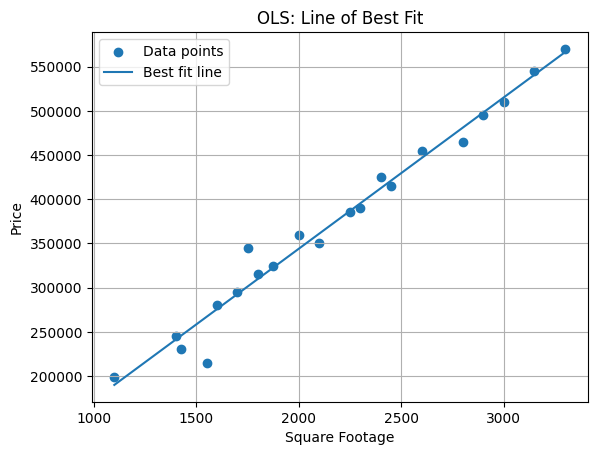

In [29]:
filepath = "/content/housing_prices - housing_prices.csv"
x_vals, y_vals = load_data(filepath)

m, b = compute_ols_parameters(x_vals, y_vals)
print(f"OLS slope m = {m}")
print(f"OLS intercept b = {b}")
sqft = 2500
predicted_price = predict(sqft, m, b)
print(f"Predicted price for {sqft} sq ft (OLS): {predicted_price:.2f}")

plot_best_fit(x_vals, y_vals, m, b)